# Estimators / clocks — Pass 2.6

Four sampling clocks on the same venue-days: **calendar**, **trade**, **tick_bounce**, **mid**.

Pre-registered Promote for bounce domination: median fifth/fourth bootstrap **CI_lo > 1.5**.


In [1]:
from pathlib import Path
import os
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = (Path(os.environ.get('ARES_MICROSTRUCTURE') or (Path.home() / 'srv' / 'ares-microstructure')) / 'research' / 'books' / 'mn_tuwrv')
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'
sys.path.insert(0, str(BOOK.parents[2]))  # ares-microstructure root

def jload(rel):
    return json.loads((OUT / rel).read_text())

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing figure* `{p}` — run `scripts/build_notebook_figs.py`'))

bc = jload('blocker_close/blocker_close.json')
gc = jload('gap_close/gap_close.json')
mc = jload('monte_carlo/mc_summary.json')
p2 = jload('pass2/pass2_gates.json')
ep = jload('expand_panel/expand_panel.json')
dp = jload('depth_predict/depth_predict.json') if (OUT/'depth_predict'/'depth_predict.json').exists() else {}
print('BOOK', BOOK)
print('figs', sorted(p.name for p in FIGS.glob('*.png')))
print('expand n_ok', ep['coverage']['n_ok'], 'depth keys', list(dp.keys())[:8])


BOOK /home/dev/srv/ares-microstructure/research/books/mn_tuwrv
figs ['fig_clock_medians.png', 'fig_gate_counts.png', 'fig_info_heatmap.png', 'fig_mc_rmse_ladder.png', 'fig_mid_venue_split.png', 'fig_noise_acf_lag1.png', 'fig_noise_vs_spread.png', 'fig_noise_vs_spread_gap_close.png', 'fig_pred_board.png', 'fig_pred_ic_noise.png', 'fig_ratio_hist.png', 'fig_signature.png', 'fig_tob_coverage.png', 'fig_tod_acf.png', 'fig_tsrv_oos.png', 'fig_venue_mid_taxonomy.png', 'signal_board.png']
expand n_ok 204 depth keys ['meta', 'information', 'predictive', 'taxonomy', 'tape_depth', 'uses', 'figures', 'decisions_rollup']


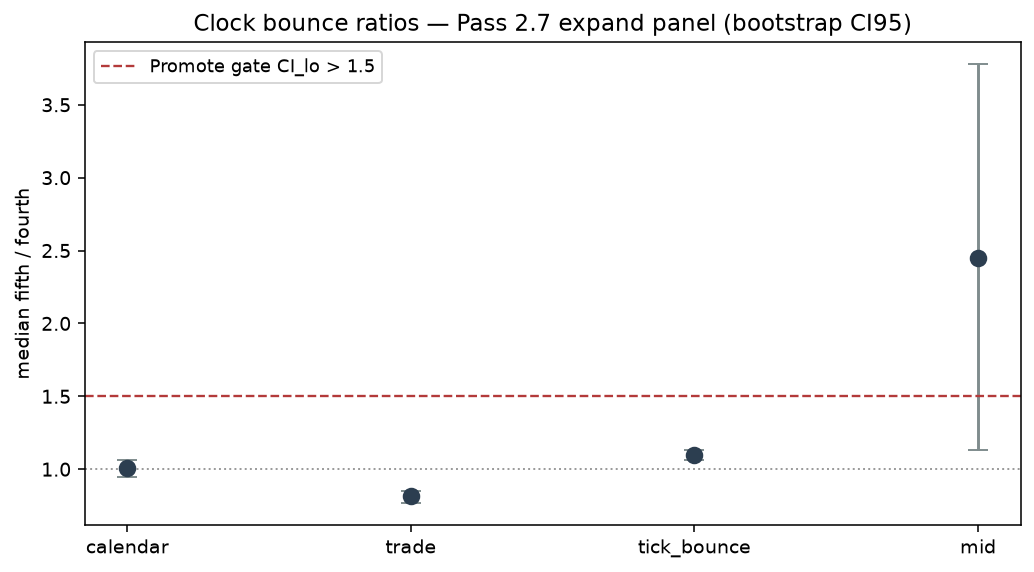

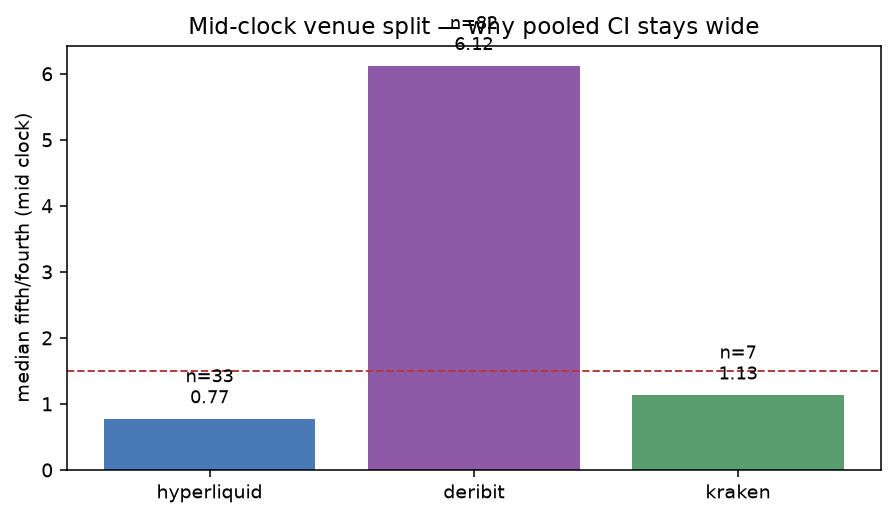

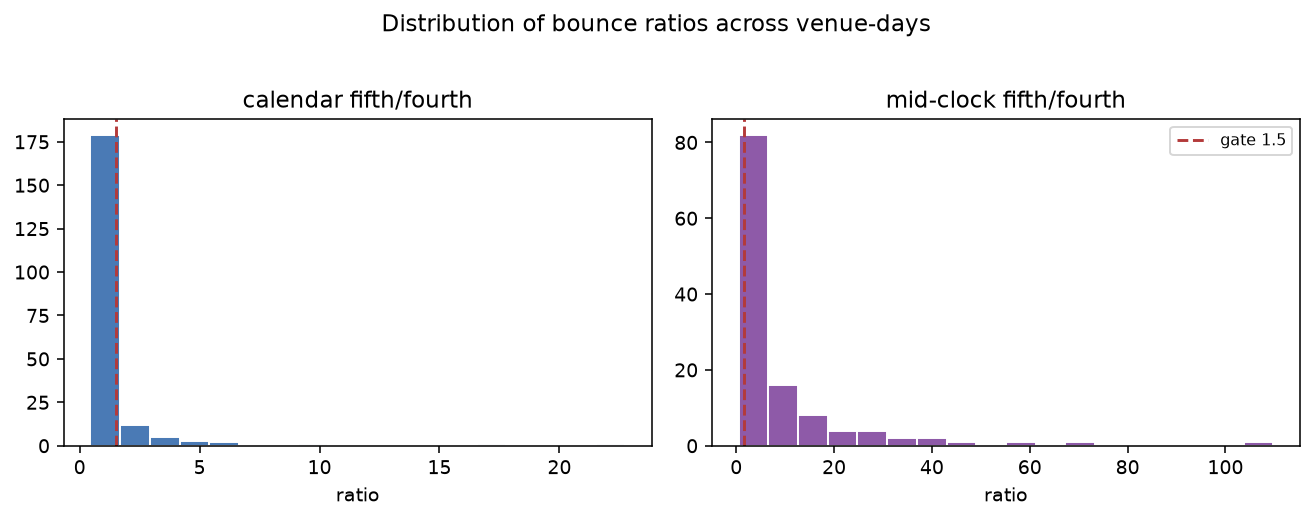

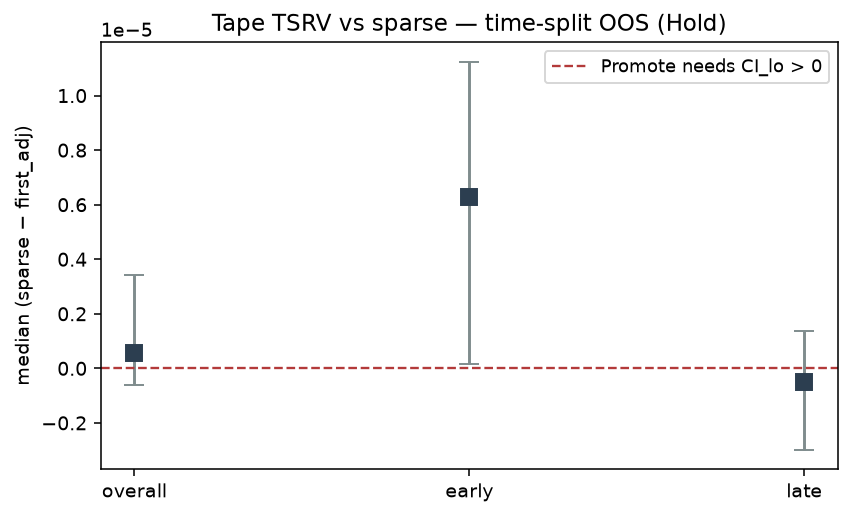

,clock,n,median,p10,p90,decision
0,calendar,204,1.005848,0.711682,1.930331,Kill
1,trade,204,0.815244,0.524696,1.509273,Kill
2,tick_bounce,203,1.096249,0.764125,1.888705,Kill
3,mid,122,2.449161,0.720932,23.671217,Hold


mid dense CI {'n': 122.0, 'median': 2.4491608334091186, 'mean': 8.607163570387224, 'se': 0.6930382906851165, 'ci95': [1.1304373276015782, 3.7767079464514177]}
tsrv OOS gate Hold fragile_rate=0.015 adv_med=5.58e-07 CI=[-5.949090895340435e-07, 3.4256954437953243e-06] SE=9.82e-07 earlyCI=[1.446921174782248e-07, 1.1235763937995365e-05] lateCI=[-2.9783714540724274e-06, 1.382499195019151e-06] ratio_med=0.9844 ratioCI=[0.

 # Estimators — EXP_REPORT (Pass 2.7 expand)

**Sample:** 34d · ETH+BTC+SOL · HL+Deribit+Kraken · **n_ok=204** · **n_mid=122**

## Clocks (fifth/fourth)

| Clock | Decision | median | CI95 | n |
|-------|----------|--------|------|---|
| calendar | **Kill** | 1.006 | [0.947, 1.065] | 204 |
| trade | **Kill** | 0.815 | [0.768, 0.853] | 204 |
| tick_bounce | **Kill** | 1.096 | [1.061, 1.129] | 203 |
| mid | **Hold** | 2.449 | [1.130, 3.777] | 122 |

Gate CI_lo>1.5 **not** met for mid (CI_lo=1.13). Venue split: HL 0.77 · Deribit 6.12 · Kraken spot 1.13.

## TSRV first_adj OOS


In [2]:
show_fig('fig_clock_medians.png')
show_fig('fig_mid_venue_split.png')
show_fig('fig_ratio_hist.png')
show_fig('fig_tsrv_oos.png')

rows = [r for r in bc['rows'] if r.get('ok')]
summary = []
for clock, key in [('calendar','fifth_over_fourth_cal'),('trade','fifth_over_fourth_tc'),
                   ('tick_bounce','fifth_over_fourth_bounce'),('mid','fifth_over_fourth_mid')]:
    vals = np.asarray([r[key] for r in rows if np.isfinite(r.get(key, np.nan))], dtype=float)
    summary.append({
        'clock': clock, 'n': int(vals.size), 'median': float(np.median(vals)) if vals.size else np.nan,
        'p10': float(np.quantile(vals,0.1)) if vals.size else np.nan,
        'p90': float(np.quantile(vals,0.9)) if vals.size else np.nan,
        'decision': bc['mid_clock']['per_clock'][clock]['decision'],
    })
display(pd.DataFrame(summary))
print('mid dense CI', bc['mid_clock']['mid_dense_ci'])
print('tsrv OOS gate', bc['tsrv_oos']['gate']['decision'], bc['tsrv_oos']['gate']['why'][:240])
print('\n', (BOOK/'chapters/estimators/EXP_REPORT.md').read_text())


### Narrative

- Calendar / trade / tick_bounce: **Kill** — ratios sit near or below 1; no bounce domination.  
- Mid-clock: **Hold** — median ~2.6 looks interesting, but CI_lo=1.17 fails the pre-registered 1.5 gate; Deribit pulls the median up, HL does not.  
- `cont.tsrv_first_adj`: **Hold** — tape sparse−tsrv advantage CI includes 0 on early and late splits.
